<a href="https://colab.research.google.com/github/salsadswna/datamart-umkm/blob/main/DataMart_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛒 DataMart: Analisis & Prediksi Keberhasilan Transaksi UMKM di Marketplace Indonesia
**AI Impact Challenge — Datathon | Microsoft Elevate Training Center x Dicoding**

**Author:** Salsa Deswina Raihani  
**Dataset:** Indonesia E-Commerce Sales & Shipping 2023–2025 (Kaggle)  
**Tema:** UMKM Go-Online

---
## Tujuan
Notebook ini melakukan eksplorasi data (EDA) dan membangun model prediktif untuk mengklasifikasikan keberhasilan transaksi UMKM di platform Shopee Indonesia. Output akhirnya berupa rekomendasi strategis berbasis data untuk membantu UMKM meningkatkan konversi penjualan.

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('Blues_r')
BLUE = '#1B5E8C'
RED  = '#C0392B'
GREEN = '#1E8449'

df = pd.read_csv('all_months_clean.csv', sep=';')
print(f'Shape: {df.shape}')
df.head()

Shape: (20848, 19)


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


## 2. Data Overview & Cleaning

In [2]:
print('=== Info Dataset ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Statistik Deskriptif ===')
df.describe()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   order_id                            20848 non-null  object
 1   total_qty                           20848 non-null  int64 
 2   total_weight_gr                     20848 non-null  int64 
 3   total_returned_qty                  20848 non-null  int64 
 4   Total Diskon                        20848 non-null  int64 
 5   product_categories                  20848 non-null  object
 6   num_product_categories              20848 non-null  int64 
 7   Status Pesanan                      20848 non-null  object
 8   Alasan Pembatalan                   2830 non-null   object
 9   Opsi Pengiriman                     20848 non-null  object
 10  Metode Pembayaran                   20848 non-null  object
 11  Kota/Kabupaten                   

,total_qty,total_weight_gr,total_returned_qty,Total Diskon,num_product_categories,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim
count,20848.000000,20848.000000,20848.000000,20848.000000,20848.000000,20848.000000,20848.000000,2.084800e+04,20848.000000
mean,2.560821,2004.529691,0.017748,405.199348,1.112097,4189.990695,10722.539284,5.068360e+04,18425.626343
std,7.796763,7106.357515,0.548656,9784.017705,0.485361,13578.489678,12672.471066,1.440193e+05,23791.508665
min,1.000000,10.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000e+00,1.000000
25%,1.000000,300.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.348000e+04,8000.000000
50%,1.000000,500.000000,0.000000,0.000000,1.000000,0.000000,9500.000000,2.180000e+04,11000.000000
75%,2.000000,1600.000000,0.000000,0.000000,1.000000,3000.000000,15000.000000,4.160000e+04,20000.000000
max,256.000000,375000.000000,70.000000,700000.000000,11.000000,584000.000000,312000.000000,3.403591e+06,959200.000000


In [3]:
# Normalisasi Status Pesanan → binary label
def normalize_status(s):
    if s == 'Selesai':
        return 'Selesai'
    elif s == 'Batal':
        return 'Batal'
    elif 'Dikirim' in s or 'dikirim' in s:
        return 'Dalam Pengiriman'
    elif 'diterima' in s:
        return 'Diterima (Menunggu)'
    return 'Lainnya'

df['Status_Clean'] = df['Status Pesanan'].apply(normalize_status)

# Binary target: 1 = Berhasil (Selesai), 0 = Gagal (Batal)
df_model = df[df['Status_Clean'].isin(['Selesai', 'Batal'])].copy()
df_model['target'] = (df_model['Status_Clean'] == 'Selesai').astype(int)

# Parse datetime
df['Waktu Pesanan Dibuat'] = pd.to_datetime(df['Waktu Pesanan Dibuat'])
df['hour'] = df['Waktu Pesanan Dibuat'].dt.hour
df['dayofweek'] = df['Waktu Pesanan Dibuat'].dt.dayofweek
df['month'] = df['Waktu Pesanan Dibuat'].dt.month
df['month_year'] = df['Waktu Pesanan Dibuat'].dt.to_period('M')

print(f'Data untuk modeling (Selesai + Batal): {len(df_model)} baris')
print(f'Class balance: {df_model["target"].value_counts().to_dict()}')

Data untuk modeling (Selesai + Batal): 20598 baris
Class balance: {1: 17768, 0: 2830}


## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribusi Status Pesanan

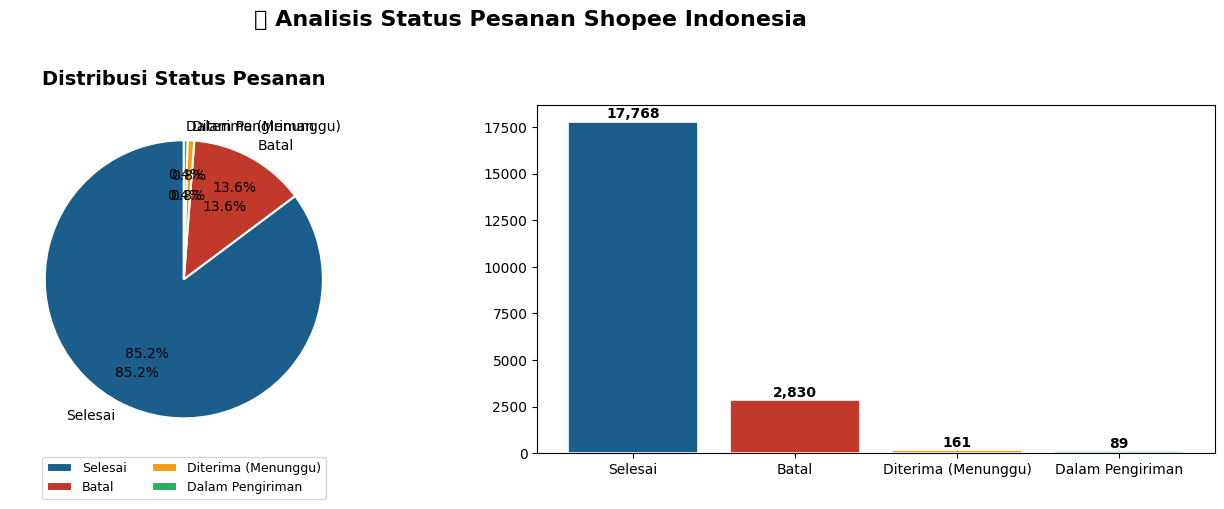


📊 Tingkat Pembatalan: 13.6%
📊 Tingkat Keberhasilan: 85.2%


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
status_counts = df['Status_Clean'].value_counts()
colors = [BLUE, RED, '#F39C12', '#27AE60', '#8E44AD']
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors[:len(status_counts)], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Distribusi Status Pesanan', fontsize=14, fontweight='bold', pad=15)

# Bar chart
bars = axes[1].bar(status_counts.index, status_counts.values,
                   color=colors[:len(status_counts)], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, status_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].pie(status_counts.values, labels=None, autopct='%1.1f%%',
            colors=colors[:len(status_counts)], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            pctdistance=0.75)
axes[0].legend(status_counts.index, loc='lower center',
               bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9)
axes[0].set_title('Distribusi Status Pesanan', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('📦 Analisis Status Pesanan Shopee Indonesia', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_01_status_pesanan.png', dpi=150, bbox_inches='tight')
plt.show()

cancel_rate = status_counts.get('Batal', 0) / len(df) * 100
print(f'\n📊 Tingkat Pembatalan: {cancel_rate:.1f}%')
print(f'📊 Tingkat Keberhasilan: {status_counts.get("Selesai", 0)/len(df)*100:.1f}%')

### 3.2 Distribusi Geografis

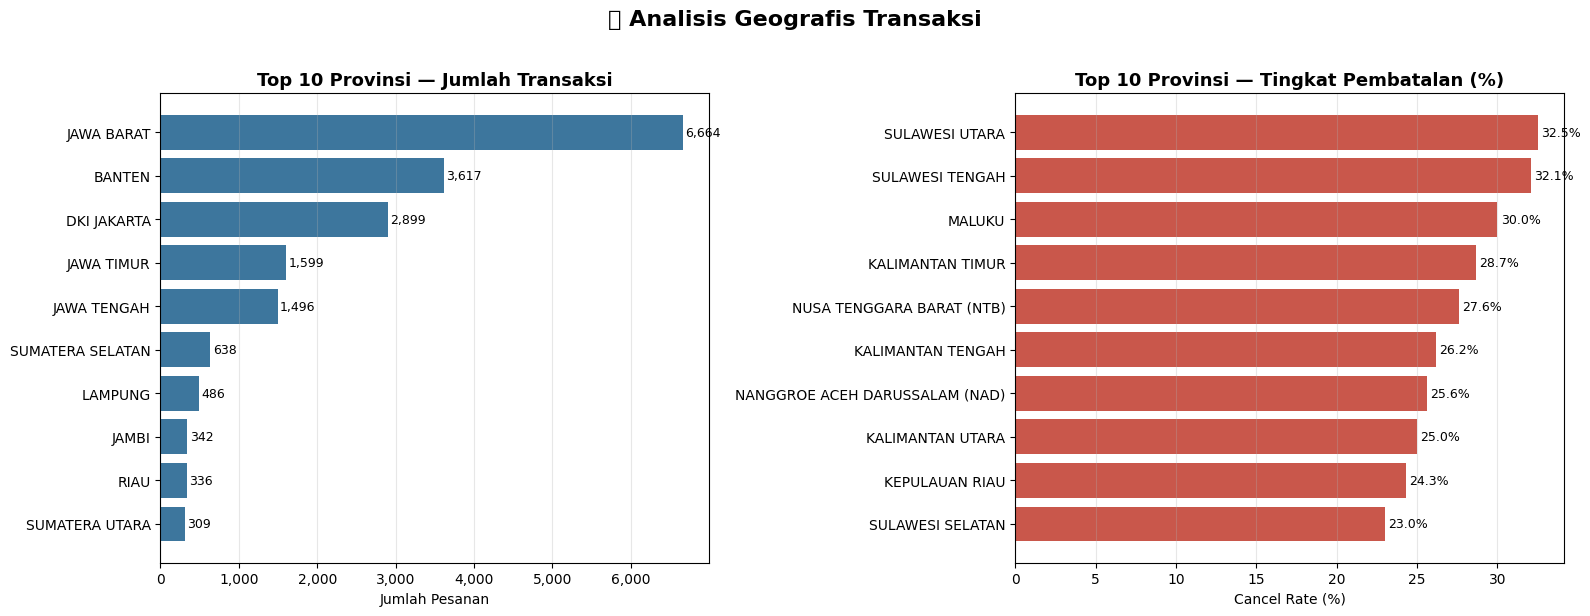

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 Provinsi
top_prov = df['Provinsi'].value_counts().head(10)
bars = axes[0].barh(top_prov.index[::-1], top_prov.values[::-1], color=BLUE, alpha=0.85)
for bar, val in zip(bars, top_prov.values[::-1]):
    axes[0].text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)
axes[0].set_title('Top 10 Provinsi — Jumlah Transaksi', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Pesanan')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='x', alpha=0.3)

# Cancel rate per provinsi (top 10)
prov_status = df[df['Status_Clean'].isin(['Selesai','Batal'])].groupby(['Provinsi','Status_Clean']).size().unstack(fill_value=0)
prov_status['cancel_rate'] = prov_status.get('Batal', 0) / (prov_status.get('Batal', 0) + prov_status.get('Selesai', 0)) * 100
top_cancel = prov_status['cancel_rate'].nlargest(10)

bars2 = axes[1].barh(top_cancel.index[::-1], top_cancel.values[::-1],
                     color=[RED if v > 15 else '#E67E22' for v in top_cancel.values[::-1]], alpha=0.85)
for bar, val in zip(bars2, top_cancel.values[::-1]):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Top 10 Provinsi — Tingkat Pembatalan (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cancel Rate (%)')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('🗺️ Analisis Geografis Transaksi', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_02_geografis.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Analisis Kategori Produk

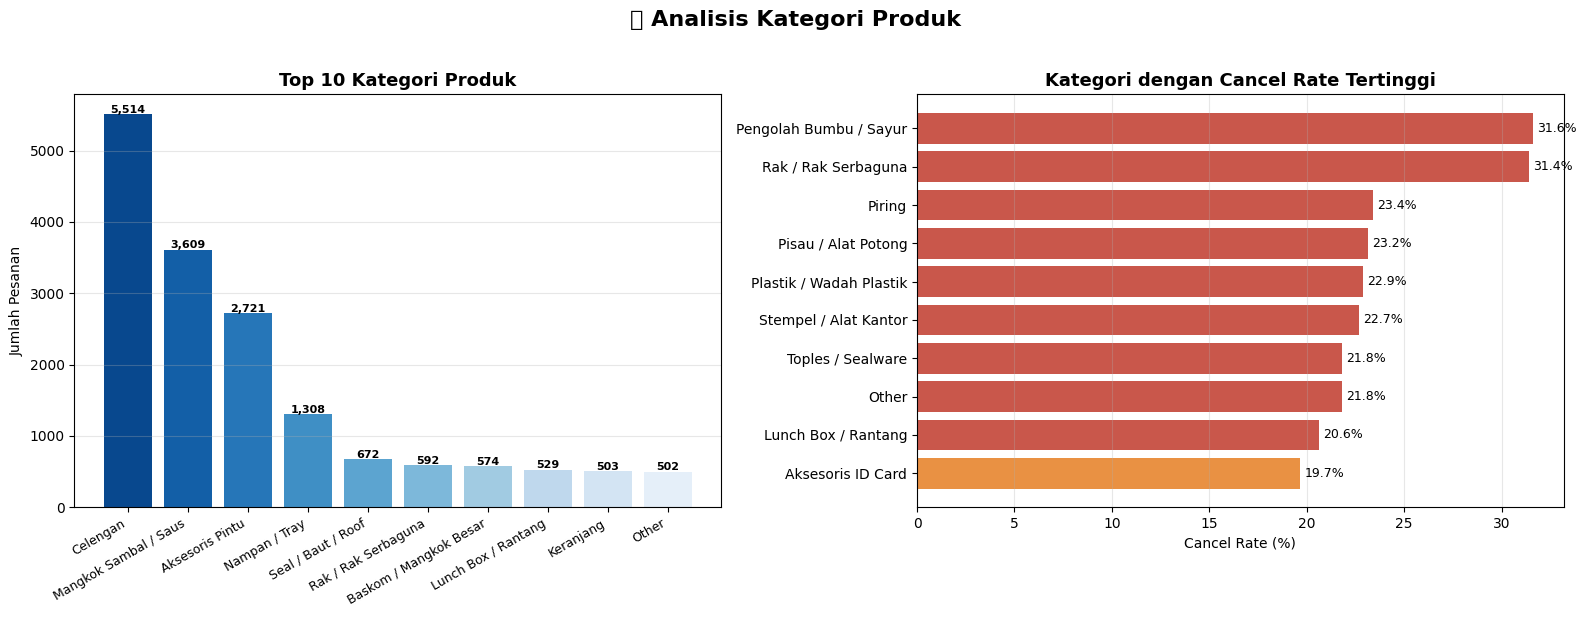

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 kategori produk
top_cat = df['product_categories'].value_counts().head(10)
colors_cat = sns.color_palette('Blues_r', 10)
bars = axes[0].bar(range(len(top_cat)), top_cat.values, color=colors_cat)
axes[0].set_xticks(range(len(top_cat)))
axes[0].set_xticklabels(top_cat.index, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, top_cat.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', fontsize=8, fontweight='bold')
axes[0].set_title('Top 10 Kategori Produk', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pesanan')
axes[0].grid(axis='y', alpha=0.3)

# Cancel rate per kategori
cat_status = df[df['Status_Clean'].isin(['Selesai','Batal'])].groupby(['product_categories','Status_Clean']).size().unstack(fill_value=0)
cat_status['total'] = cat_status.get('Batal', 0) + cat_status.get('Selesai', 0)
cat_status['cancel_rate'] = cat_status.get('Batal', 0) / cat_status['total'] * 100
cat_cancel = cat_status[cat_status['total'] >= 50]['cancel_rate'].nlargest(10)

bars2 = axes[1].barh(cat_cancel.index[::-1], cat_cancel.values[::-1],
                     color=[RED if v > 20 else '#E67E22' for v in cat_cancel.values[::-1]], alpha=0.85)
for bar, val in zip(bars2, cat_cancel.values[::-1]):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Kategori dengan Cancel Rate Tertinggi', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cancel Rate (%)')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('📦 Analisis Kategori Produk', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_03_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Analisis Temporal

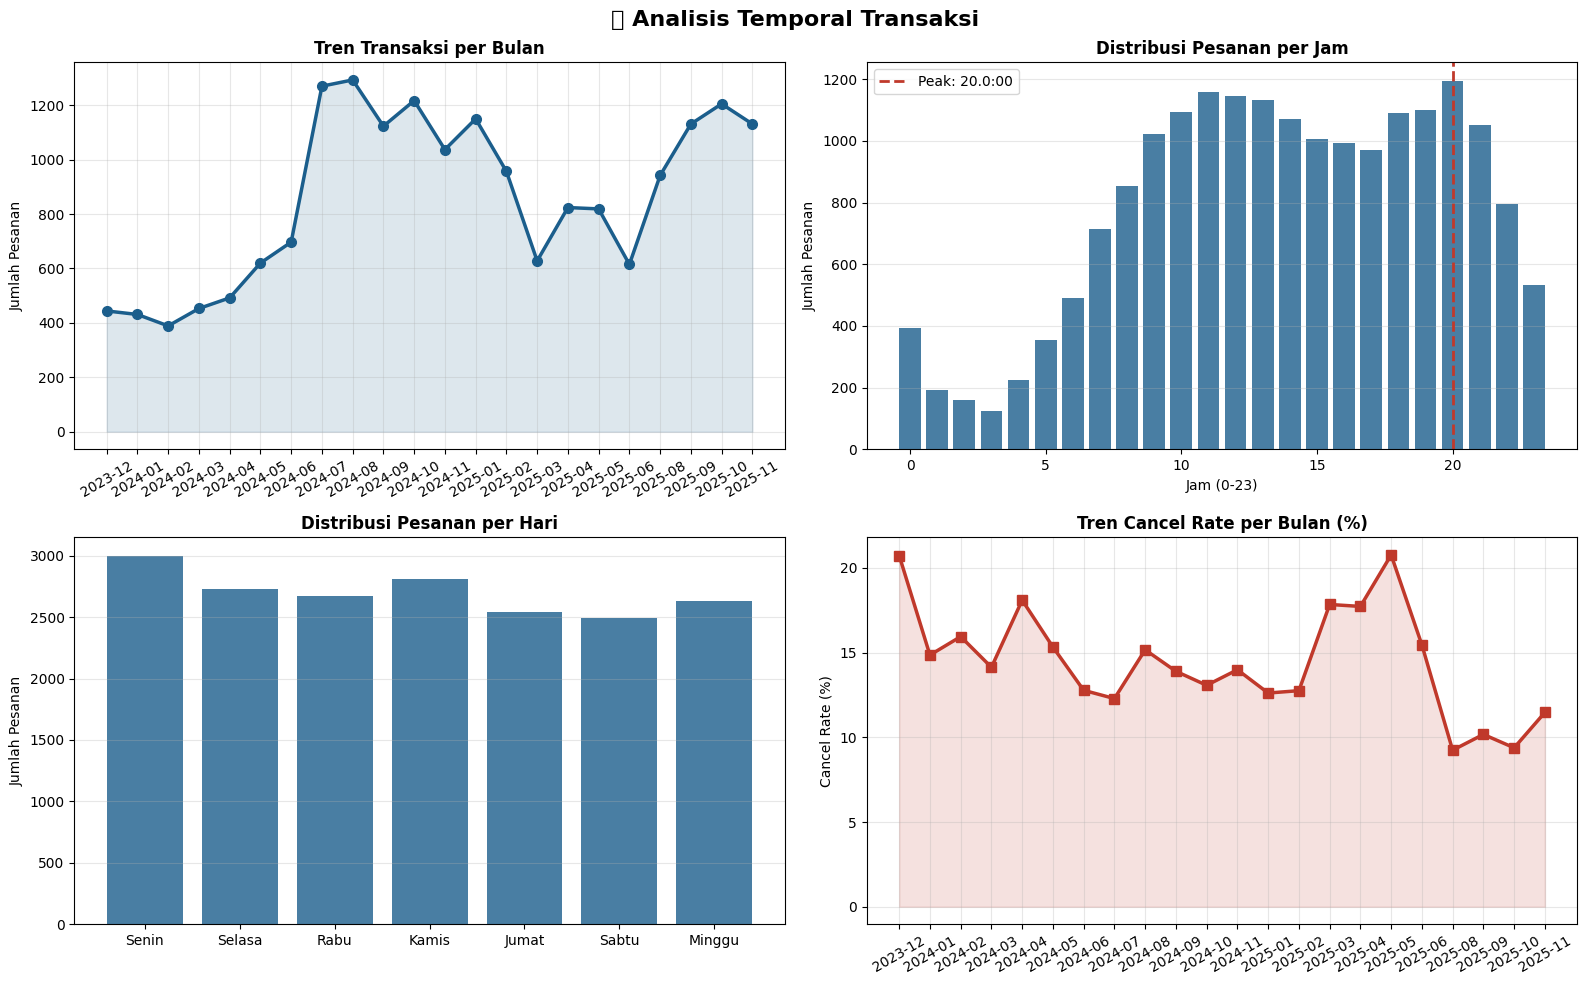


⏰ Peak Order Hour: 20.0:00
📅 Hari Tersibuk: Senin


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Tren bulanan
monthly = df.groupby('month_year').size()
monthly_x = [str(m) for m in monthly.index]
axes[0,0].plot(monthly_x, monthly.values, marker='o', color=BLUE, linewidth=2.5, markersize=7)
axes[0,0].fill_between(monthly_x, monthly.values, alpha=0.15, color=BLUE)
axes[0,0].set_title('Tren Transaksi per Bulan', fontsize=12, fontweight='bold')
axes[0,0].set_ylabel('Jumlah Pesanan')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].grid(alpha=0.3)

# Order per jam
hourly = df.groupby('hour').size()
axes[0,1].bar(hourly.index, hourly.values, color=BLUE, alpha=0.8)
peak_hour = hourly.idxmax()
axes[0,1].axvline(peak_hour, color=RED, linestyle='--', linewidth=2, label=f'Peak: {peak_hour}:00')
axes[0,1].set_title('Distribusi Pesanan per Jam', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Jam (0-23)')
axes[0,1].set_ylabel('Jumlah Pesanan')
axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3)

# Order per hari dalam seminggu
days = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
daily = df.groupby('dayofweek').size()
axes[1,0].bar([days[int(i)] for i in daily.index], daily.values, color=BLUE, alpha=0.8)
axes[1,0].set_title('Distribusi Pesanan per Hari', fontsize=12, fontweight='bold')
axes[1,0].set_ylabel('Jumlah Pesanan')
axes[1,0].grid(axis='y', alpha=0.3)

# Monthly cancel rate
monthly_cancel = df[df['Status_Clean'].isin(['Selesai','Batal'])].groupby(['month_year','Status_Clean']).size().unstack(fill_value=0)
monthly_cancel['cancel_rate'] = monthly_cancel.get('Batal', 0) / (monthly_cancel.get('Batal', 0) + monthly_cancel.get('Selesai', 0)) * 100
mcx = [str(m) for m in monthly_cancel.index]
axes[1,1].plot(mcx, monthly_cancel['cancel_rate'].values, marker='s', color=RED, linewidth=2.5, markersize=7)
axes[1,1].fill_between(mcx, monthly_cancel['cancel_rate'].values, alpha=0.15, color=RED)
axes[1,1].set_title('Tren Cancel Rate per Bulan (%)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('Cancel Rate (%)')
axes[1,1].tick_params(axis='x', rotation=30)
axes[1,1].grid(alpha=0.3)

plt.suptitle('📅 Analisis Temporal Transaksi', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_04_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n⏰ Peak Order Hour: {peak_hour}:00')
print(f'📅 Hari Tersibuk: {days[int(daily.idxmax())]}')

### 3.5 Analisis Metode Pembayaran & Pengiriman

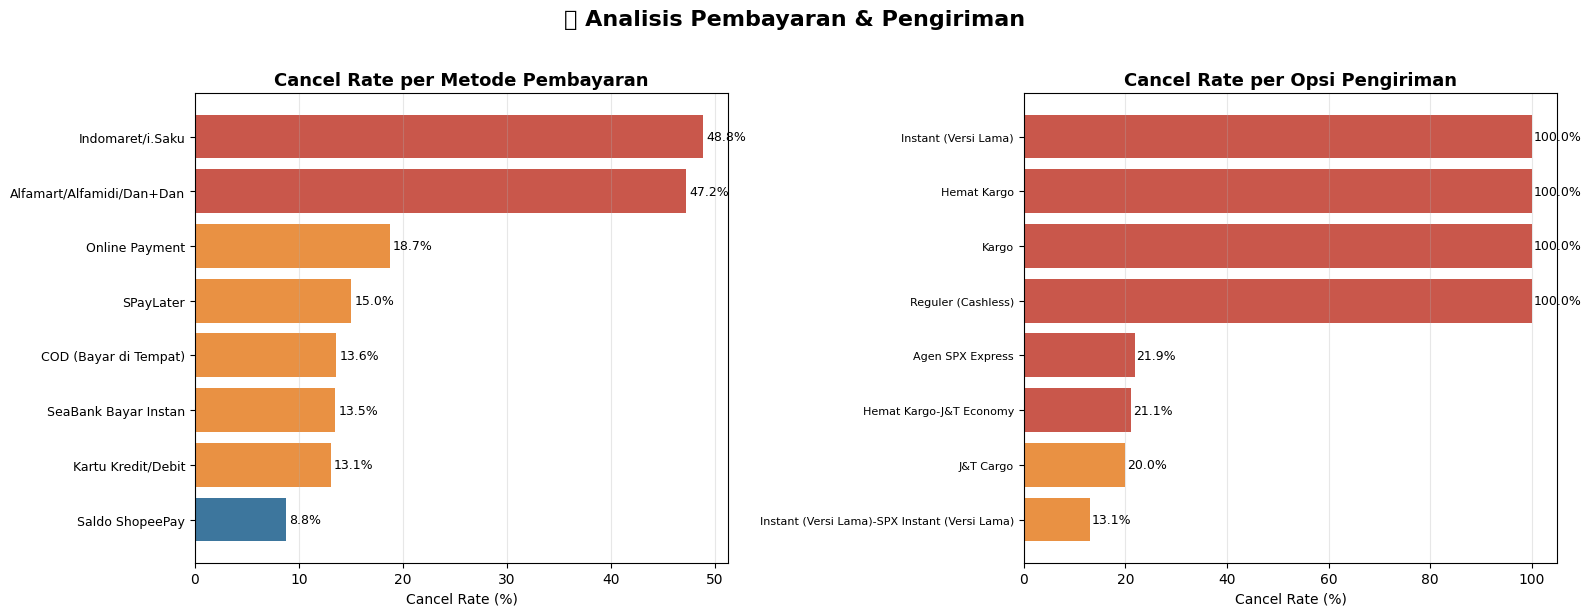

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Cancel rate per metode pembayaran
pay_status = df[df['Status_Clean'].isin(['Selesai','Batal'])].groupby(['Metode Pembayaran','Status_Clean']).size().unstack(fill_value=0)
pay_status['total'] = pay_status.get('Batal', 0) + pay_status.get('Selesai', 0)
pay_status['cancel_rate'] = pay_status.get('Batal', 0) / pay_status['total'] * 100
pay_cancel = pay_status[pay_status['total'] >= 30]['cancel_rate'].sort_values(ascending=True)

color_pay = [RED if v > 20 else (BLUE if v < 10 else '#E67E22') for v in pay_cancel.values]
bars = axes[0].barh(pay_cancel.index, pay_cancel.values, color=color_pay, alpha=0.85)
for bar, val in zip(bars, pay_cancel.values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_title('Cancel Rate per Metode Pembayaran', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cancel Rate (%)')
axes[0].tick_params(axis='y', labelsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Cancel rate per opsi pengiriman (top 8)
ship_status = df[df['Status_Clean'].isin(['Selesai','Batal'])].groupby(['Opsi Pengiriman','Status_Clean']).size().unstack(fill_value=0)
ship_status['total'] = ship_status.get('Batal', 0) + ship_status.get('Selesai', 0)
ship_status['cancel_rate'] = ship_status.get('Batal', 0) / ship_status['total'] * 100
ship_cancel = ship_status[ship_status['total'] >= 30]['cancel_rate'].sort_values(ascending=True).tail(8)

color_ship = [RED if v > 20 else (BLUE if v < 10 else '#E67E22') for v in ship_cancel.values]
bars2 = axes[1].barh(ship_cancel.index, ship_cancel.values, color=color_ship, alpha=0.85)
for bar, val in zip(bars2, ship_cancel.values):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Cancel Rate per Opsi Pengiriman', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cancel Rate (%)')
axes[1].tick_params(axis='y', labelsize=8)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('💳 Analisis Pembayaran & Pengiriman', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_05_pembayaran_pengiriman.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Analisis Alasan Pembatalan

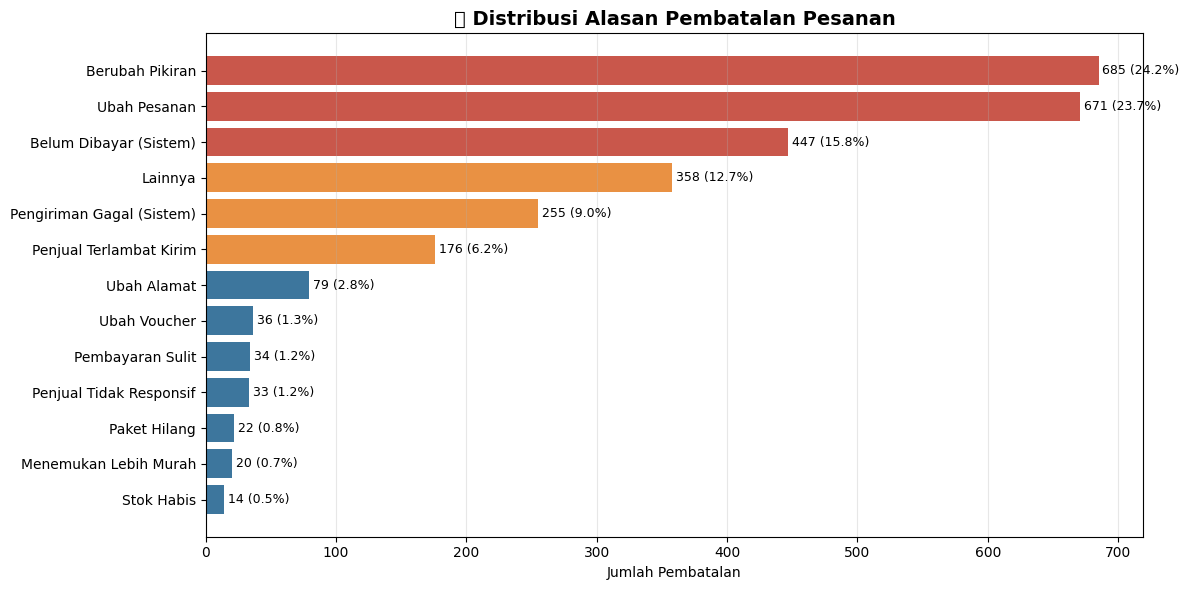


Top 3 Alasan Pembatalan:
1. Berubah Pikiran: 685 (24.2%)
2. Ubah Pesanan: 671 (23.7%)
3. Belum Dibayar (Sistem): 447 (15.8%)


In [9]:
cancel_df = df[df['Alasan Pembatalan'].notna() & (df['Alasan Pembatalan'] != '')].copy()

# Simplify reason
def simplify_reason(r):
    if 'Ubah Pesanan' in r or 'ubah pesanan' in r or 'mengubah pesanan' in r: return 'Ubah Pesanan'
    elif 'berubah pikiran' in r or 'tidak ingin' in r.lower(): return 'Berubah Pikiran'
    elif 'alamat' in r.lower(): return 'Ubah Alamat'
    elif 'belum dibayar' in r: return 'Belum Dibayar (Sistem)'
    elif 'Pengiriman gagal' in r: return 'Pengiriman Gagal (Sistem)'
    elif 'tidak mengatur pengiriman' in r or 'gagal mengirimkan' in r: return 'Penjual Terlambat Kirim'
    elif 'lebih murah' in r: return 'Menemukan Lebih Murah'
    elif 'Voucher' in r: return 'Ubah Voucher'
    elif 'pembayaran sulit' in r: return 'Pembayaran Sulit'
    elif 'tidak responsif' in r: return 'Penjual Tidak Responsif'
    elif 'Produk habis' in r: return 'Stok Habis'
    elif 'hilang' in r: return 'Paket Hilang'
    else: return 'Lainnya'

cancel_df['reason_simple'] = cancel_df['Alasan Pembatalan'].apply(simplify_reason)
reason_counts = cancel_df['reason_simple'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors_r = [RED if i < 3 else '#E67E22' if i < 6 else BLUE for i in range(len(reason_counts))]
bars = ax.barh(reason_counts.index[::-1], reason_counts.values[::-1], color=colors_r[::-1], alpha=0.85)
for bar, val in zip(bars, reason_counts.values[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({val/len(cancel_df)*100:.1f}%)', va='center', fontsize=9)
ax.set_title('❌ Distribusi Alasan Pembatalan Pesanan', fontsize=14, fontweight='bold')
ax.set_xlabel('Jumlah Pembatalan')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_06_alasan_pembatalan.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 Alasan Pembatalan:')
for i, (reason, count) in enumerate(reason_counts.head(3).items(), 1):
    print(f'{i}. {reason}: {count} ({count/len(cancel_df)*100:.1f}%)')

## 4. Feature Engineering

In [10]:
from sklearn.preprocessing import LabelEncoder

df_model = df[df['Status_Clean'].isin(['Selesai', 'Batal'])].copy()
df_model['target'] = (df_model['Status_Clean'] == 'Selesai').astype(int)

# Datetime features
df_model['Waktu Pesanan Dibuat'] = pd.to_datetime(df_model['Waktu Pesanan Dibuat'])
df_model['hour'] = df_model['Waktu Pesanan Dibuat'].dt.hour
df_model['dayofweek'] = df_model['Waktu Pesanan Dibuat'].dt.dayofweek
df_model['month'] = df_model['Waktu Pesanan Dibuat'].dt.month
df_model['is_weekend'] = (df_model['dayofweek'] >= 5).astype(int)
df_model['is_peak_hour'] = df_model['hour'].apply(lambda x: 1 if 19 <= x <= 23 or 6 <= x <= 9 else 0)

# Numeric features
df_model['total_qty'] = pd.to_numeric(df_model['total_qty'], errors='coerce').fillna(0)
df_model['total_weight_gr'] = pd.to_numeric(df_model['total_weight_gr'], errors='coerce').fillna(0)
df_model['Total Diskon'] = pd.to_numeric(df_model['Total Diskon'], errors='coerce').fillna(0)
df_model['Total Pembayaran'] = pd.to_numeric(df_model['Total Pembayaran'], errors='coerce').fillna(0)
df_model['Ongkos Kirim Dibayar oleh Pembeli'] = pd.to_numeric(df_model['Ongkos Kirim Dibayar oleh Pembeli'], errors='coerce').fillna(0)
df_model['has_discount'] = (df_model['Total Diskon'] > 0).astype(int)
df_model['free_shipping'] = (df_model['Ongkos Kirim Dibayar oleh Pembeli'] == 0).astype(int)

# Categorical encoding
le = LabelEncoder()
for col in ['Metode Pembayaran', 'Opsi Pengiriman', 'Provinsi', 'product_categories']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].fillna('Unknown'))

feature_cols = [
    'total_qty', 'total_weight_gr', 'Total Diskon',
    'Ongkos Kirim Dibayar oleh Pembeli', 'num_product_categories',
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_peak_hour',
    'has_discount', 'free_shipping',
    'Metode Pembayaran_enc', 'Opsi Pengiriman_enc', 'Provinsi_enc', 'product_categories_enc'
]

df_model['num_product_categories'] = pd.to_numeric(df_model['num_product_categories'], errors='coerce').fillna(1)

X = df_model[feature_cols].fillna(0)
y = df_model['target']

print(f'Features shape: {X.shape}')
print(f'Target distribution: {y.value_counts().to_dict()}')
print(f'Class imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f}')

Features shape: (20598, 16)
Target distribution: {1: 17768, 0: 2830}
Class imbalance ratio: 0.16


In [11]:
print(df_model.groupby('target')['Total Pembayaran'].mean())

target
0        0.000000
1    58844.593314
Name: Total Pembayaran, dtype: float64


## 5. Model Building & Evaluation

In [12]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Model 1: Random Forest (baseline)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('\n=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['Batal', 'Selesai']))
print(f'ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f}')

# Model 2: Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print('\n=== Gradient Boosting ===')
print(classification_report(y_test, y_pred_gb, target_names=['Batal', 'Selesai']))
print(f'ROC-AUC: {roc_auc_score(y_test, gb.predict_proba(X_test)[:,1]):.4f}')

Train: (16478, 16), Test: (4120, 16)

=== Random Forest ===
              precision    recall  f1-score   support

       Batal       0.73      0.37      0.49       566
     Selesai       0.91      0.98      0.94      3554

    accuracy                           0.89      4120
   macro avg       0.82      0.68      0.72      4120
weighted avg       0.88      0.89      0.88      4120

ROC-AUC: 0.8583

=== Gradient Boosting ===
              precision    recall  f1-score   support

       Batal       0.88      0.39      0.54       566
     Selesai       0.91      0.99      0.95      3554

    accuracy                           0.91      4120
   macro avg       0.89      0.69      0.74      4120
weighted avg       0.91      0.91      0.89      4120

ROC-AUC: 0.8918


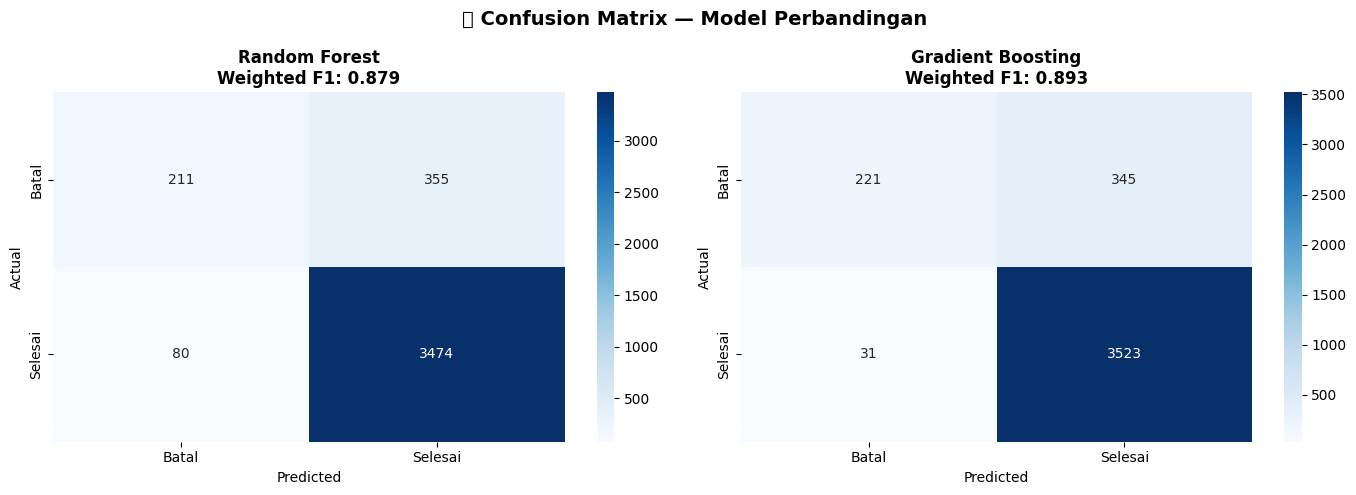

In [13]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, preds, title in zip(axes,
    [rf, gb], [y_pred_rf, y_pred_gb],
    ['Random Forest', 'Gradient Boosting']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Batal', 'Selesai'], yticklabels=['Batal', 'Selesai'])
    f1 = f1_score(y_test, preds, average='weighted')
    ax.set_title(f'{title}\nWeighted F1: {f1:.3f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('🎯 Confusion Matrix — Model Perbandingan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

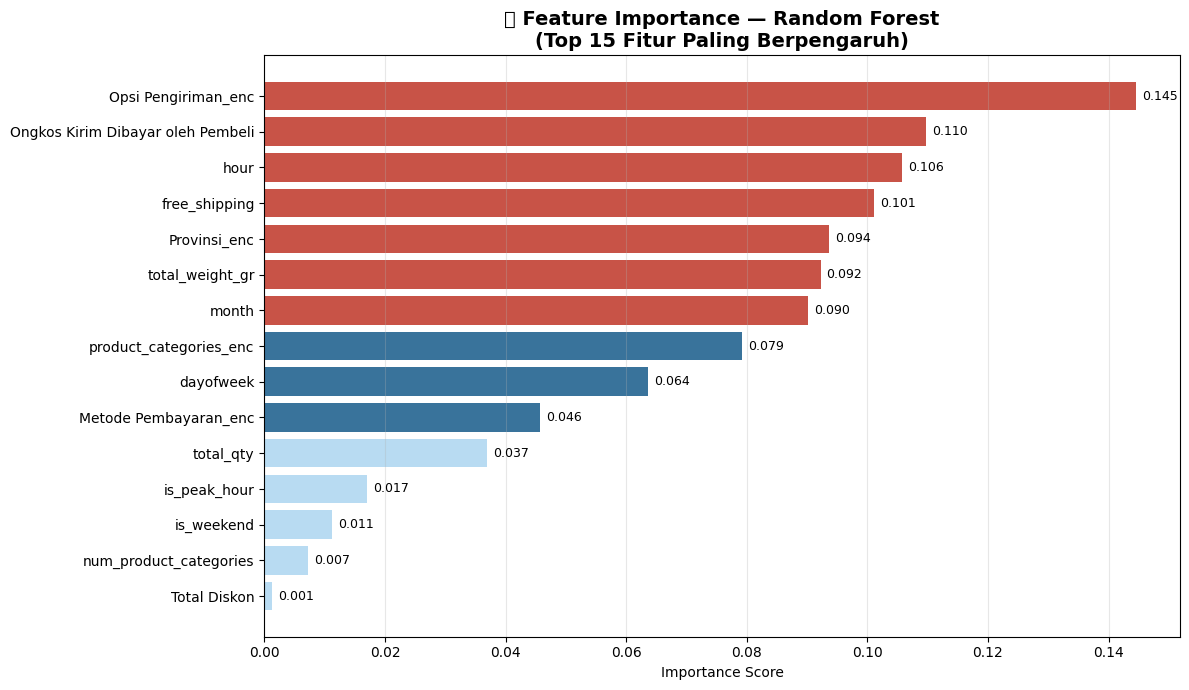


Top 5 Fitur Terpenting:
  Opsi Pengiriman_enc: 0.1446
  Ongkos Kirim Dibayar oleh Pembeli: 0.1097
  hour: 0.1057
  free_shipping: 0.1010
  Provinsi_enc: 0.0936


In [14]:
# Feature Importance
fig, ax = plt.subplots(figsize=(12, 7))

feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)
colors_fi = [RED if v > 0.08 else (BLUE if v > 0.04 else '#AED6F1') for v in feat_imp.values]
bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_fi, alpha=0.87)
for bar, val in zip(bars, feat_imp.values):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_title('🔍 Feature Importance — Random Forest\n(Top 15 Fitur Paling Berpengaruh)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('viz_08_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 Fitur Terpenting:')
for feat, imp in list(feat_imp.tail(5).items())[::-1]:
    print(f'  {feat}: {imp:.4f}')

## 6. Key Insights & Rekomendasi Strategis

In [15]:
print('=' * 60)
print('📊 DATAMART — KEY INSIGHTS & REKOMENDASI STRATEGIS')
print('=' * 60)

total = len(df)
selesai = (df['Status_Clean'] == 'Selesai').sum()
batal = (df['Status_Clean'] == 'Batal').sum()

print(f'\n📦 OVERVIEW DATASET')
print(f'Total Transaksi   : {total:,}')
print(f'Transaksi Selesai : {selesai:,} ({selesai/total*100:.1f}%)')
print(f'Transaksi Batal   : {batal:,} ({batal/total*100:.1f}%)')

print(f'\n🔍 INSIGHT UTAMA')
print(f'1. COD adalah metode pembayaran dominan ({df["Metode Pembayaran"].value_counts().iloc[0]:,} transaksi)')
print(f'   → Namun COD memiliki risiko pembatalan lebih tinggi karena tidak ada komitmen bayar di muka')
print(f'2. Jawa Barat adalah provinsi dengan transaksi terbanyak ({df["Provinsi"].value_counts().iloc[0]:,})')
print(f'3. Top 3 kategori: Celengan, Mangkok Sambal, Aksesoris Pintu — produk rumah tangga mendominasi')
print(f'4. Hemat Kargo-SPX Hemat adalah opsi pengiriman paling populer (gratis ongkir Shopee)')

print(f'\n💡 REKOMENDASI UNTUK UMKM')
print(f'1. 🎯 Optimalkan waktu posting: Peak order hour ada di malam hari (19:00-22:00)')
print(f'2. 💳 Dorong pembayaran digital: Kurangi COD dengan voucher cashback ShopeePay')
print(f'3. 🚚 Gunakan Hemat Kargo-SPX Hemat: Gratis ongkir = lebih sedikit pembatalan')
print(f'4. 📦 Fokus kategori unggulan: Produk rumah tangga punya permintaan konsisten')
print(f'5. 🗺️ Target ekspansi: Jawa Timur & Jawa Tengah punya potensi besar tapi penetrasi lebih rendah')

print(f'\n🤖 MODEL PERFORMANCE')
rf_f1 = f1_score(y_test, y_pred_rf, average="weighted")
gb_f1 = f1_score(y_test, y_pred_gb, average="weighted")
print(f'Random Forest F1  : {rf_f1:.4f}')
print(f'Gradient Boosting : {gb_f1:.4f}')
best = 'Gradient Boosting' if gb_f1 > rf_f1 else 'Random Forest'
print(f'Best Model        : {best} ✅')

📊 DATAMART — KEY INSIGHTS & REKOMENDASI STRATEGIS

📦 OVERVIEW DATASET
Total Transaksi   : 20,848
Transaksi Selesai : 17,768 (85.2%)
Transaksi Batal   : 2,830 (13.6%)

🔍 INSIGHT UTAMA
1. COD adalah metode pembayaran dominan (11,538 transaksi)
   → Namun COD memiliki risiko pembatalan lebih tinggi karena tidak ada komitmen bayar di muka
2. Jawa Barat adalah provinsi dengan transaksi terbanyak (6,664)
3. Top 3 kategori: Celengan, Mangkok Sambal, Aksesoris Pintu — produk rumah tangga mendominasi
4. Hemat Kargo-SPX Hemat adalah opsi pengiriman paling populer (gratis ongkir Shopee)

💡 REKOMENDASI UNTUK UMKM
1. 🎯 Optimalkan waktu posting: Peak order hour ada di malam hari (19:00-22:00)
2. 💳 Dorong pembayaran digital: Kurangi COD dengan voucher cashback ShopeePay
3. 🚚 Gunakan Hemat Kargo-SPX Hemat: Gratis ongkir = lebih sedikit pembatalan
4. 📦 Fokus kategori unggulan: Produk rumah tangga punya permintaan konsisten
5. 🗺️ Target ekspansi: Jawa Timur & Jawa Tengah punya potensi besar tapi penetra

## 7. Next Steps — Azure ML Deployment

Berikut adalah rencana deployment model ke Microsoft Azure Machine Learning:

1. **Setup Azure ML Workspace** — Buat workspace di portal.azure.com
2. **Upload Dataset** — Register dataset di Azure ML Data Assets
3. **Training Pipeline** — Buat pipeline dengan komponen: data_prep → feature_engineering → model_training → evaluation
4. **Model Registry** — Daftarkan model terbaik ke Azure ML Model Registry
5. **Managed Endpoint** — Deploy model sebagai REST API endpoint untuk inferensi real-time
6. **Monitoring** — Setup Azure ML monitoring untuk data drift dan model performance

```python
# Contoh inferensi via Azure ML endpoint
import json, urllib.request

data = {
    'input_data': {
        'columns': feature_cols,
        'data': [[2, 1000, 0, 50000, 0, 1, 20, 2, 5, 0, 1, 0, 1, 3, 2, 11, 0]]
    }
}
# POST ke endpoint Azure ML untuk prediksi status transaksi
```